### Data Quality report for `Wie is De Mol S16E05`


### Dataset Profile
**Average sentence length, vocabulary size, token distributions:** 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

data_dir = "..\\data\\transcription\\csv\\sentences.csv"

In [7]:
# Load the dataset
df = pd.read_csv(data_dir)

print("--- Dataset Profile ---")
print(f"Dataset size: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

--- Dataset Profile ---
Dataset size: (1083, 3)

Missing values per column:
sentence      0
start_time    0
end_time      0
dtype: int64

Number of duplicate rows: 0


In [9]:
# Calculate sentence length
df['sentence_length'] = df['sentence'].apply(lambda x: len(str(x).split()))
print(f"\nAverage sentence length: {df['sentence_length'].mean():.2f} words")


Average sentence length: 7.00 words


In [12]:
# Vocabulary size and token distribution
all_words = ' '.join(df['sentence'].dropna()).lower()
words = re.findall(r'\b\w+\b', all_words)
vocabulary = set(words)
print(f"Vocabulary size: {len(vocabulary)} unique words")

word_counts = Counter(words)
most_common_words = word_counts.most_common(20)
print("\nTop 20 most frequent words:")
for word, count in most_common_words:
    print(f"{word} : {count}")

Vocabulary size: 1411 unique words

Top 20 most frequent words:
ik : 242
het : 242
de : 236
en : 164
is : 155
dat : 152
een : 147
je : 130
c : 117
u : 113
van : 96
we : 95
die : 86
ja : 85
niet : 81
met : 79
op : 78
in : 71
er : 65
aan : 60


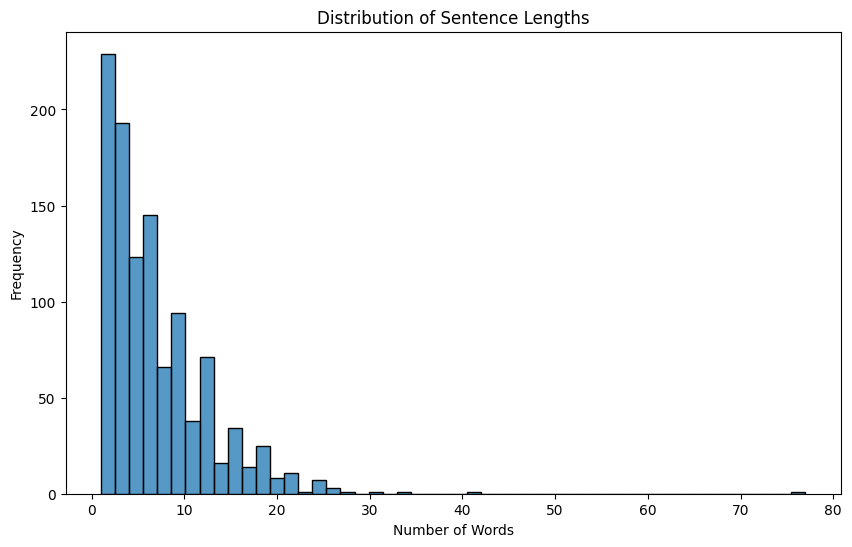

In [13]:
# Visualize sentence length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['sentence_length'], bins=50)
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()



***

### 2. Speaker and Show Distributions

This step will analyze the distribution of speakers and TV shows to identify any dominance that could lead to model bias.

* **Code Description:** We'll create bar charts or pie charts using matplotlib or seaborn to visualize the number of entries per speaker and per show. We'll also calculate the percentage of the data that each speaker and show represents.
* **Expected Output:** We'll present visualizations showing the top speakers and shows. We'll identify if a small number of speakers or shows account for a disproportionately large part of the dataset, which would signal a potential for overfitting. This will highlight the need for a more diverse training set.

***

### 3. Emotion Distribution and Coverage

This section focuses on the distribution and representation of emotions within the dataset.

* **Code Description:** We'll use a bar chart to show the frequency of each annotated emotion. We'll also calculate the percentage of the dataset that each emotion represents.
* **Expected Output:** The visualization will show the distribution of emotions. We'll look for significant class imbalances, where some emotions (e.g., "joy," "anger") are well-represented, while others (e.g., "disappointment," "fear") are very rare. This will confirm if certain emotions are **underrepresented**, which would necessitate gathering more data for those specific classes.

***

### 4. Domain Characteristics

Here, we'll dive into the linguistic patterns specific to spoken television.

* **Code Description:** We'll perform a qualitative analysis on a sample of the data. We'll write a Python script to search for and count common spoken language features like **fillers** ("um," "uh"), **hesitations**, and **slang**. We'll also look for **interruptions** by analyzing the sequence of speaker turns.
* **Expected Output:** We'll provide examples of these linguistic patterns and discuss their frequency. We'll highlight how the language is informal and conversational, and how these features differ from written text. This analysis will guide the preprocessing steps for the model, ensuring it can handle these natural speech characteristics. 

***

### 5. Data Quality Checks

This step is crucial for identifying and correcting inconsistencies in the data.

* **Code Description:** We'll manually inspect a random subset of transcriptions and their corresponding emotion labels. We'll look for **mislabeled emotions** (e.g., a clearly angry utterance labeled as "joy"), spelling errors, and encoding issues. We'll also use simple string analysis to identify potential transcription artifacts or inconsistencies.
* **Expected Output:** We'll report on the quality of the data. We'll provide examples of mislabeled or erroneous data points and suggest a strategy for correction. This step will ensure that the model isn't learning from noisy or incorrect labels, which is a major pitfall.

***

### 6. Reflection for Training Data Selection

Based on the analysis, this final section will summarize the findings and recommend a strategy for acquiring external training data.

* **Code Description:** No new code. This is a summary and a conclusion based on the previous steps.
* **Analysis and Conclusion:**
    * **Gaps Identified:** We'll summarize the gaps found in the dataset, such as **imbalanced emotion classes**, **overrepresentation of certain speakers or shows**, and a potential lack of **specific genres** (e.g., news broadcasts, documentaries, reality TV).
    * **Data Acquisition Strategy:** We'll propose gathering external data that specifically addresses these gaps. For example, we'll need to find datasets with more balanced emotion distributions, or data from a wider variety of TV genres and regional variations. We'll emphasize the need for data that includes natural **interruptions** and **fillers** to make the model more robust to real-world conversational speech. 
    * **Preventing Overfitting:** We will conclude by emphasizing that the model's success depends on a **diverse and representative training set** that mirrors the full spectrum of spoken TV language, rather than just the specific characteristics of the chosen initial dataset.